## 1. Install Dependencies

In [1]:
!pip install ultralytics -q
!pip install opencv-python-headless -q
!pip install huggingface_hub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.9 MB/s eta 0:00:00


## 2. Imports & Configuration

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P2595.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P0524.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P1651.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P2242.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P2789.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P1128.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P1179.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P1742.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P2135.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P2420.png
/kaggle/input/datasets/divyadharshinis22

In [3]:
import os, shutil, json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import cv2
import yaml
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_INPUT  = Path('/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA')
BASE_OUTPUT = Path('/kaggle/working/dota_yolo')

TRAIN_IMGS  = BASE_INPUT / 'train' / 'images'
TRAIN_LBLS  = BASE_INPUT / 'train' / 'labelTxt'
VAL_IMGS    = BASE_INPUT / 'val'   / 'images'
VAL_LBLS    = BASE_INPUT / 'val'   / 'labelTxt'
TEST_IMGS   = BASE_INPUT / 'test'  / 'images'

# ── DOTA v1.0 class list (order matters – index = class id) ───────────────
DOTA_CLASSES = [
    'plane', 'ship', 'storage-tank', 'baseball-diamond',
    'tennis-court', 'basketball-court', 'ground-track-field',
    'harbor', 'bridge', 'large-vehicle', 'small-vehicle',
    'helicopter', 'roundabout', 'soccer-ball-field', 'swimming-pool'
]
CLASS2ID = {c: i for i, c in enumerate(DOTA_CLASSES)}

# ── Device – use GPU if available, otherwise CPU ───────────────────────────
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}  ({"GPU" if DEVICE == 0 else "CPU"})')

# ── Colour palette (shared by all visualisation cells) ────────────────────
COLORS         = matplotlib.colormaps.get_cmap('tab20').resampled(len(DOTA_CLASSES))
BUILDING_COLOR = (0.1, 0.9, 0.1)   # dashed green for buildings

print('Classes:', DOTA_CLASSES)
print('Train images :', len(list(TRAIN_IMGS.glob('*.png'))))
print('Val   images :', len(list(VAL_IMGS.glob('*.png'))))
print('Test  images :', len(list(TEST_IMGS.glob('*.png'))))


# ══════════════════════════════════════════════════════════════════════════
# Shared helpers – defined once, used throughout the notebook
# ══════════════════════════════════════════════════════════════════════════

def parse_yolo_labels(lbl_path):
    """Read a YOLO-format label file.
    Returns list of (cls_id, cx, cy, bw, bh, conf) – all values normalised [0,1].
    conf defaults to 1.0 when not present (ground-truth labels).
    """
    path = Path(lbl_path)
    if not path.exists():
        return []
    detections = []
    for line in path.read_text().strip().split('\n'):
        if not line:
            continue
        parts  = line.split()
        cls_id = int(parts[0])
        cx, cy, bw, bh = map(float, parts[1:5])
        conf   = float(parts[5]) if len(parts) > 5 else 1.0
        detections.append((cls_id, cx, cy, bw, bh, conf))
    return detections


def merge_boxes_by_class(detections):
    """Merge all bounding boxes of the same class into one union bounding box.

    Args:
        detections: list of (cls_id, cx, cy, bw, bh [, conf])  – normalised [0,1]
    Returns:
        list of (cls_id, x1, y1, x2, y2, max_conf)
    """
    from collections import defaultdict
    buckets = defaultdict(list)
    for det in detections:
        cls_id         = det[0]
        cx, cy, bw, bh = det[1], det[2], det[3], det[4]
        conf           = det[5] if len(det) > 5 else 1.0
        buckets[cls_id].append((cx - bw / 2, cy - bh / 2,
                                cx + bw / 2, cy + bh / 2, conf))
    merged = []
    for cls_id, boxes in buckets.items():
        x1   = min(b[0] for b in boxes)
        y1   = min(b[1] for b in boxes)
        x2   = max(b[2] for b in boxes)
        y2   = max(b[3] for b in boxes)
        best = max(b[4] for b in boxes)
        merged.append((cls_id, x1, y1, x2, y2, best))
    return merged

Device : 0  (GPU)
Classes: ['plane', 'ship', 'storage-tank', 'baseball-diamond', 'tennis-court', 'basketball-court', 'ground-track-field', 'harbor', 'bridge', 'large-vehicle', 'small-vehicle', 'helicopter', 'roundabout', 'soccer-ball-field', 'swimming-pool']
Train images : 1411
Val   images : 458
Test  images : 937


## 3. DOTA → YOLO Label Conversion

In [4]:
def parse_dota_label(label_path: Path):
    """Parse a DOTA labelTxt file and return list of (class_name, x1,y1,x2,y2,x3,y3,x4,y4)."""
    instances = []
    with open(label_path, 'r') as f:
        for line in f:
            line = line.strip()
            # Skip metadata header lines
            if not line or line.startswith('imagesource') or line.startswith('gsd') or line.startswith('acquisition'):
                continue
            parts = line.split()
            if len(parts) < 10:
                continue
            coords = list(map(float, parts[:8]))   # x1 y1 x2 y2 x3 y3 x4 y4
            category  = parts[8].lower().replace(' ', '-')
            # difficult = int(parts[9])  # 0 or 1
            instances.append((category, coords))
    return instances


def obb_to_hbb_yolo(coords, img_w, img_h):
    """Convert OBB [x1,y1,...,x4,y4] to normalised YOLO [cx, cy, w, h]."""
    xs = coords[0::2]   # x1 x2 x3 x4
    ys = coords[1::2]   # y1 y2 y3 y4
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    cx = (x_min + x_max) / 2 / img_w
    cy = (y_min + y_max) / 2 / img_h
    w  = (x_max - x_min) / img_w
    h  = (y_max - y_min) / img_h
    # Clamp to [0, 1]
    cx = max(0.0, min(1.0, cx))
    cy = max(0.0, min(1.0, cy))
    w  = max(0.0, min(1.0, w))
    h  = max(0.0, min(1.0, h))
    return cx, cy, w, h


def convert_split(img_dir: Path, lbl_dir: Path, out_img_dir: Path, out_lbl_dir: Path,
                  class2id: dict, symlink_images: bool = True):
    """Convert all images+labels in a split to YOLO format."""
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    skipped, converted = 0, 0
    img_files = sorted(img_dir.glob('*.png'))

    for img_path in tqdm(img_files, desc=f'Converting {img_dir.parent.name}'):
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if not lbl_path.exists():
            skipped += 1
            continue

        # Get image dimensions without loading full image
        img = Image.open(img_path)
        img_w, img_h = img.size
        img.close()

        instances = parse_dota_label(lbl_path)
        yolo_lines = []
        for cat, coords in instances:
            if cat not in class2id:
                continue   # skip unknown categories
            cls_id = class2id[cat]
            cx, cy, w, h = obb_to_hbb_yolo(coords, img_w, img_h)
            yolo_lines.append(f'{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}')

        # Write YOLO label file
        out_lbl = out_lbl_dir / (img_path.stem + '.txt')
        with open(out_lbl, 'w') as f:
            f.write('\n'.join(yolo_lines))

        # Symlink or copy image
        out_img = out_img_dir / img_path.name
        if not out_img.exists():
            if symlink_images:
                out_img.symlink_to(img_path.resolve())
            else:
                shutil.copy2(img_path, out_img)
        converted += 1

    print(f'  → converted: {converted}  |  skipped (no label): {skipped}')


# Run conversions
convert_split(TRAIN_IMGS, TRAIN_LBLS,
              BASE_OUTPUT/'images/train', BASE_OUTPUT/'labels/train',
              CLASS2ID)

convert_split(VAL_IMGS, VAL_LBLS,
              BASE_OUTPUT/'images/val', BASE_OUTPUT/'labels/val',
              CLASS2ID)

# Test set – no labels, just symlink images for inference later
(BASE_OUTPUT/'images/test').mkdir(parents=True, exist_ok=True)
for img_path in tqdm(sorted(TEST_IMGS.glob('*.png')), desc='Linking test images'):
    out_img = BASE_OUTPUT / 'images/test' / img_path.name
    if not out_img.exists():
        out_img.symlink_to(img_path.resolve())

print('\nDataset structure ready at:', BASE_OUTPUT)

Converting train: 100%|██████████| 1411/1411 [00:14<00:00, 95.55it/s] 


  → converted: 1411  |  skipped (no label): 0


Converting val: 100%|██████████| 458/458 [00:04<00:00, 110.43it/s]


  → converted: 458  |  skipped (no label): 0


Linking test images: 100%|██████████| 937/937 [00:00<00:00, 1601.74it/s]


Dataset structure ready at: /kaggle/working/dota_yolo


## 4. Write dataset.yaml

In [5]:
dataset_yaml = {
    'path'  : str(BASE_OUTPUT),
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',
    'nc'    : len(DOTA_CLASSES),
    'names' : DOTA_CLASSES
}

yaml_path = BASE_OUTPUT / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, sort_keys=False)

print('dataset.yaml written:')
print(open(yaml_path).read())

dataset.yaml written:
path: /kaggle/working/dota_yolo
train: images/train
val: images/val
test: images/test
nc: 15
names:
- plane
- ship
- storage-tank
- baseball-diamond
- tennis-court
- basketball-court
- ground-track-field
- harbor
- bridge
- large-vehicle
- small-vehicle
- helicopter
- roundabout
- soccer-ball-field
- swimming-pool



## 5. Visualise a Few Training Samples

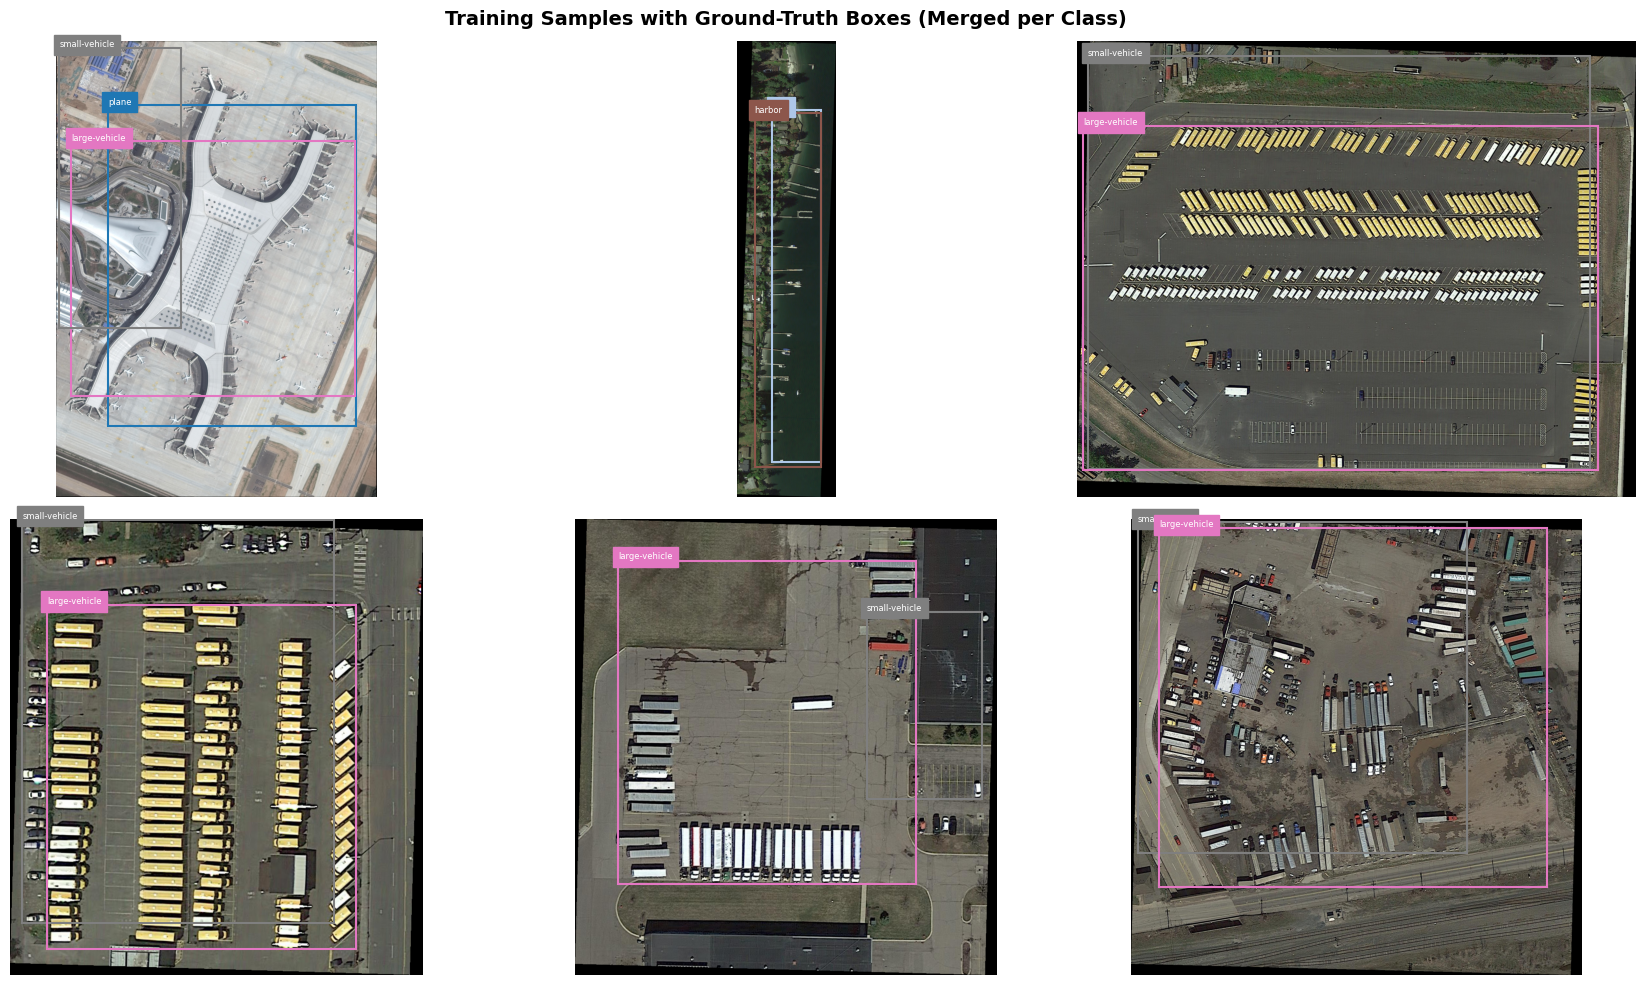

In [6]:
def show_yolo_sample(img_path, lbl_path, class_names, ax):
    """Draw one merged union box per class over a training sample."""
    img = np.array(Image.open(img_path).convert('RGB'))
    h, w = img.shape[:2]
    ax.imshow(img)

    raw = parse_yolo_labels(lbl_path)
    for cls_id, x1, y1, x2, y2, _ in merge_boxes_by_class(raw):
        px1, py1 = x1 * w, y1 * h
        pw,  ph  = (x2 - x1) * w, (y2 - y1) * h
        ax.add_patch(patches.Rectangle(
            (px1, py1), pw, ph,
            linewidth=1.5, edgecolor=COLORS(cls_id), facecolor='none'
        ))
        ax.text(px1, py1 - 3, class_names[cls_id], fontsize=6,
                color='white', backgroundcolor=COLORS(cls_id))
    ax.axis('off')

img_files = sorted((BASE_OUTPUT / 'images/train').glob('*.png'))[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, img_path in zip(axes.flatten(), img_files):
    lbl_path = BASE_OUTPUT / 'labels/train' / (img_path.stem + '.txt')
    show_yolo_sample(img_path, lbl_path, DOTA_CLASSES, ax)
plt.suptitle('Training Samples with Ground-Truth Boxes (Merged per Class)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/train_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Class Distribution Analysis

             Class  Train  Val
             plane   8055 2531
              ship  28068 8960
      storage-tank   5029 2888
  baseball-diamond    415  214
      tennis-court   2367  760
  basketball-court    515  132
ground-track-field    325  144
            harbor   5983 2090
            bridge   2047  464
     large-vehicle  16969 4387
     small-vehicle  26126 5438
        helicopter    630   73
        roundabout    399  179
 soccer-ball-field    326  153
     swimming-pool   1736  440


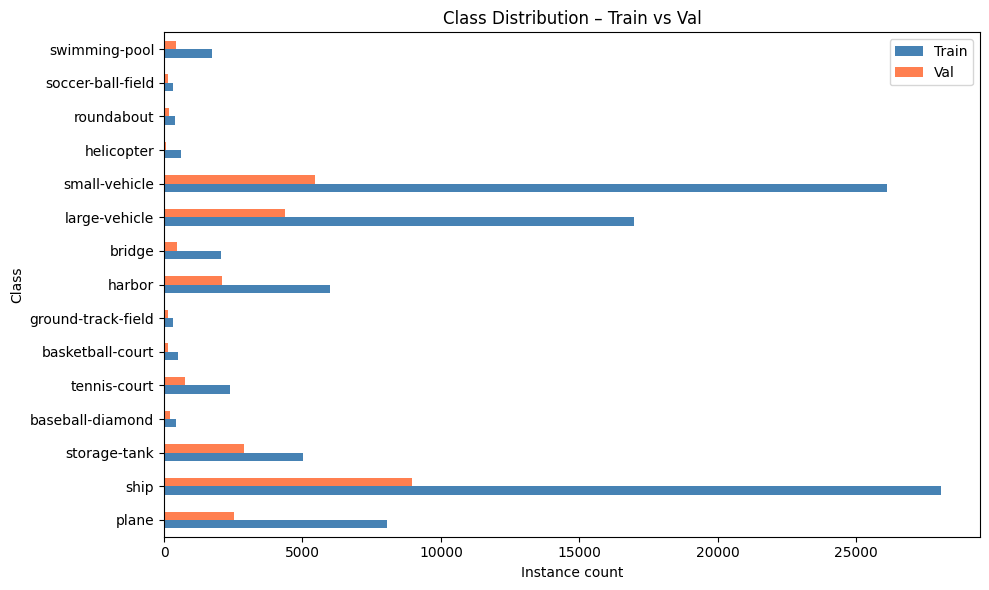

In [7]:
from collections import Counter

def count_classes(lbl_dir: Path):
    """Count per-class instances across all label files in a directory."""
    counts = Counter()
    for f in lbl_dir.glob('*.txt'):
        for det in parse_yolo_labels(f):
            counts[det[0]] += 1
    return counts

train_counts = count_classes(BASE_OUTPUT / 'labels/train')
val_counts   = count_classes(BASE_OUTPUT / 'labels/val')

df_dist = pd.DataFrame({
    'Class' : DOTA_CLASSES,
    'Train' : [train_counts.get(i, 0) for i in range(len(DOTA_CLASSES))],
    'Val'   : [val_counts.get(i,   0) for i in range(len(DOTA_CLASSES))],
})
print(df_dist.to_string(index=False))

df_dist.set_index('Class').plot(kind='barh', figsize=(10, 6),
                                color=['steelblue', 'coral'])
plt.xlabel('Instance count')
plt.title('Class Distribution – Train vs Val')
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png', dpi=120)
plt.show()

## 7. Train YOLOv8

In [8]:
import gc
from ultralytics import YOLO

model = YOLO('yolov8m.pt')

results = model.train(
    data          = str(yaml_path),
    epochs        = 150,
    imgsz         = 1024,
    batch         = -1,
    workers       = 4,
    cache         = False,
    project       = '/kaggle/working/runs',
    name          = 'dota_yolov8m',
    pretrained    = True,
    optimizer     = 'AdamW',
    lr0           = 0.001,
    lrf           = 0.01,
    weight_decay  = 0.0005,
    warmup_epochs = 3,
    mosaic        = 1.0,
    degrees       = 15.0,
    flipud        = 0.5,
    fliplr        = 0.5,
    hsv_h         = 0.015,
    hsv_s         = 0.7,
    hsv_v         = 0.4,
    scale         = 0.5,
    patience      = 20,
    save          = True,
    save_period   = 10,
    device        = DEVICE,
    amp           = True,
    verbose       = True,
    seed          = 42,
)

del model
gc.collect()
if DEVICE == 0:
    import torch; torch.cuda.empty_cache()
print('Training complete – GPU memory released.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dota_yolo/dataset.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_

## 8. Validation – mAP Metrics

In [9]:
import gc

best_weights = Path('/kaggle/working/runs/dota_yolov8m/weights/best.pt')
model_best   = YOLO(str(best_weights))

val_metrics = model_best.val(
    data    = str(yaml_path),
    imgsz   = 1024,
    batch   = 4,
    device  = DEVICE,
    split   = 'val',
    verbose = True,
)

print('\n=== Validation Results ===')
print(f'mAP50    : {val_metrics.box.map50:.4f}')
print(f'mAP50-95 : {val_metrics.box.map:.4f}')
print(f'Precision: {val_metrics.box.mp:.4f}')
print(f'Recall   : {val_metrics.box.mr:.4f}')

gc.collect()
if DEVICE == 0:
    import torch; torch.cuda.empty_cache()

Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,848,445 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2872.2±910.3 MB/s, size: 4013.5 KB)
val: Scanning /kaggle/working/dota_yolo/labels/val.cache... 458 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 458/458 174.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 115/115 3.1it/s 37.3s
                   all        458      28853      0.706      0.547      0.547      0.322
                 plane         70       2531      0.804      0.752      0.755       0.47
                  ship        108       8960       0.86      0.613      0.619      0.351
          storage-tank         55       2888      0.849      0.373      0.416      0.217
      baseball-diamond         53        214      0.807      0.589      0.683      0.376
          tennis-court         94 

## 9. Per-Class AP Table

             Class    AP@50
      tennis-court 0.931908
     large-vehicle 0.789186
             plane 0.754629
            harbor 0.716175
  baseball-diamond 0.683440
              ship 0.618502
     small-vehicle 0.576620
  basketball-court 0.520883
ground-track-field 0.475313
     swimming-pool 0.453214
      storage-tank 0.415769
 soccer-ball-field 0.406791
        roundabout 0.315820
        helicopter 0.292330
            bridge 0.252549


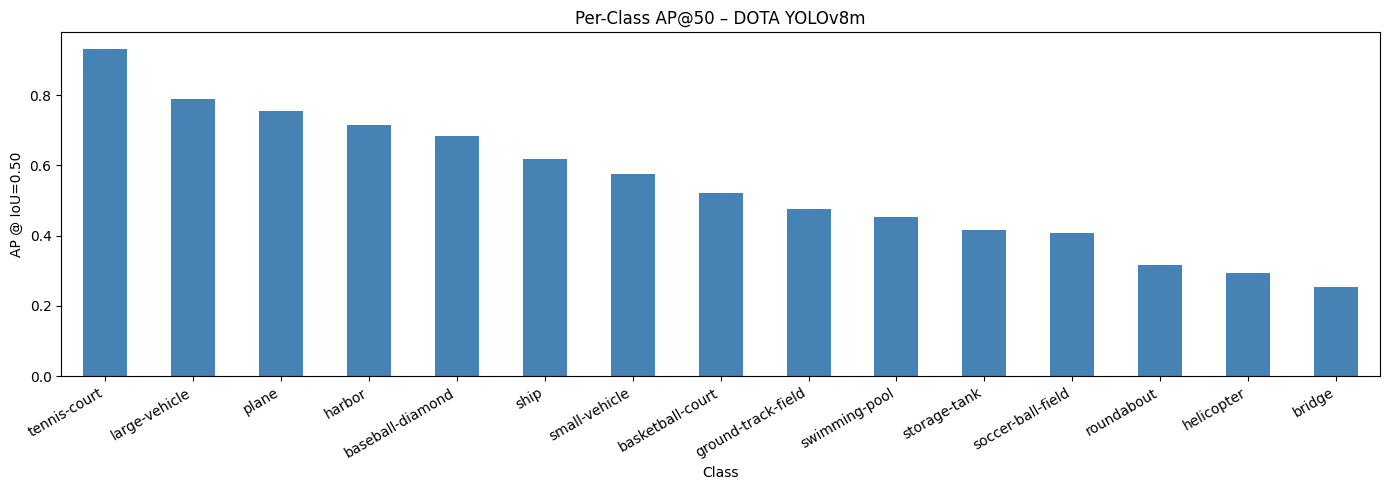

In [10]:
ap_per_class = val_metrics.box.ap50  # array of AP50 per class

df_ap = pd.DataFrame({
    'Class'  : DOTA_CLASSES,
    'AP@50'  : ap_per_class
}).sort_values('AP@50', ascending=False)

print(df_ap.to_string(index=False))

# Bar chart
df_ap.plot(x='Class', y='AP@50', kind='bar', figsize=(14, 5),
           color='steelblue', legend=False)
plt.xticks(rotation=30, ha='right')
plt.ylabel('AP @ IoU=0.50')
plt.title('Per-Class AP@50 – DOTA YOLOv8m')
plt.tight_layout()
plt.savefig('/kaggle/working/per_class_ap.png', dpi=120)
plt.show()

## 10. Training Curves

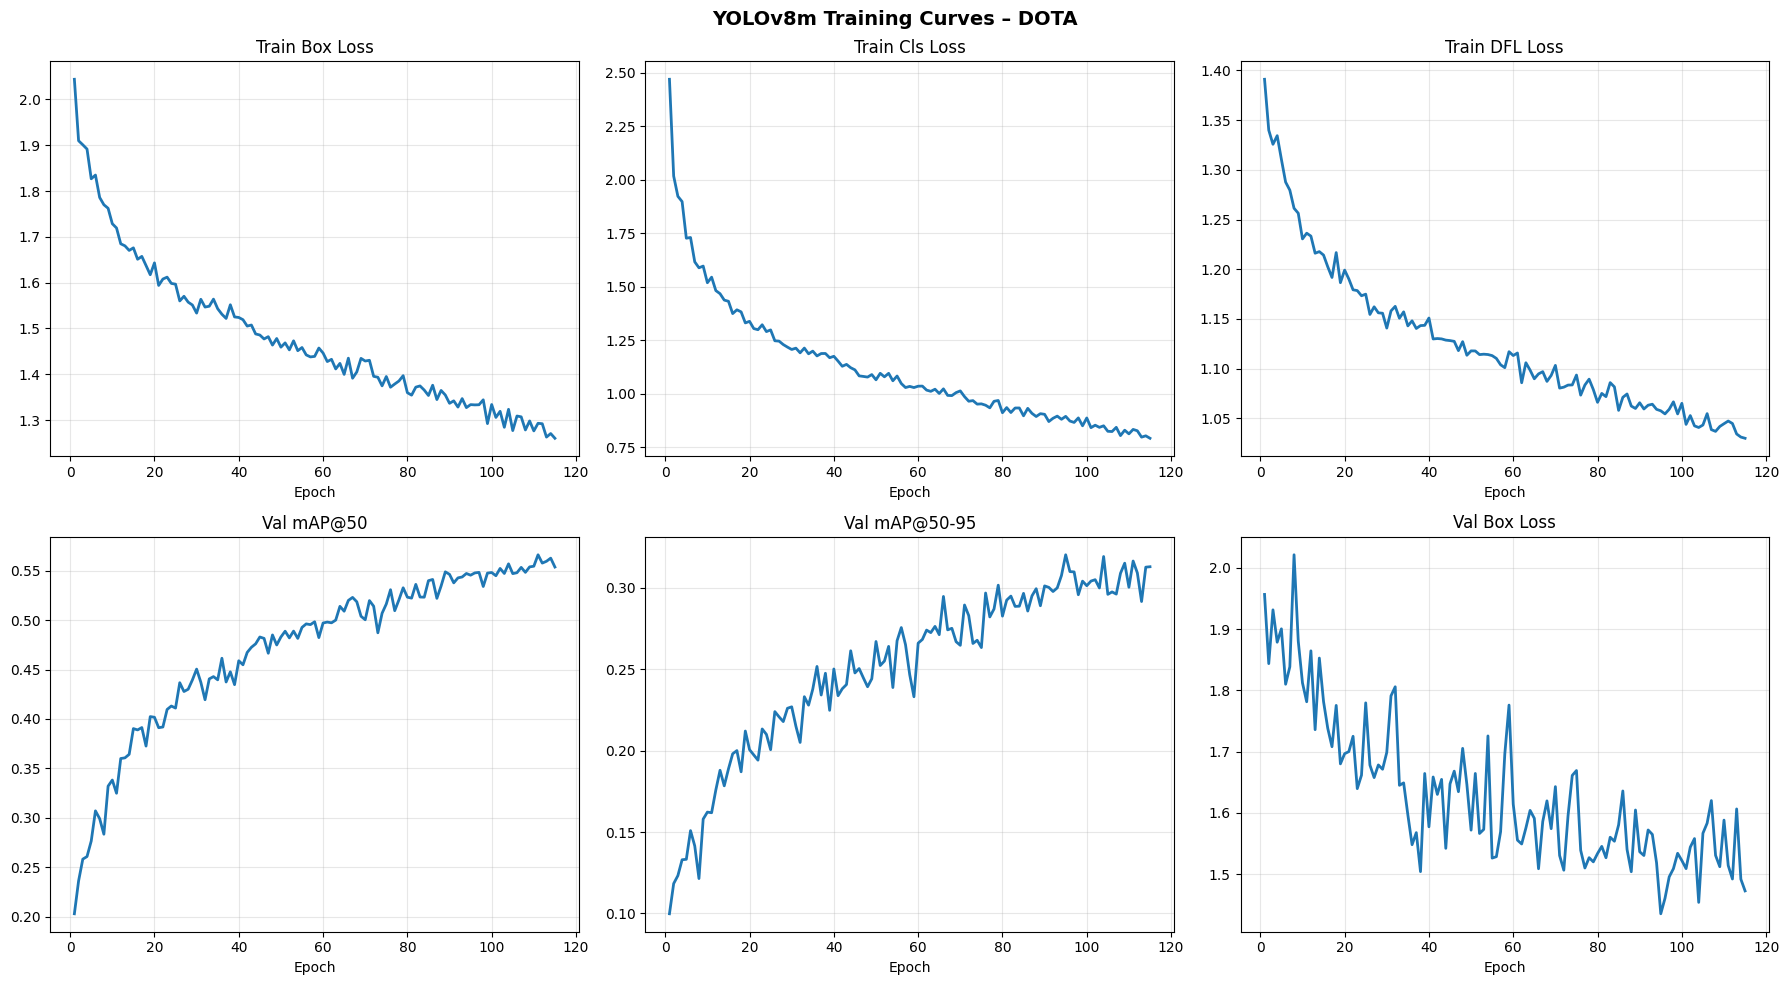

In [11]:
results_csv = Path('/kaggle/working/runs/dota_yolov8m/results.csv')
df_results  = pd.read_csv(results_csv)
df_results.columns = df_results.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_cols = [
    ('train/box_loss',   'Train Box Loss'),
    ('train/cls_loss',   'Train Cls Loss'),
    ('train/dfl_loss',   'Train DFL Loss'),
    ('metrics/mAP50(B)', 'Val mAP@50'),
    ('metrics/mAP50-95(B)', 'Val mAP@50-95'),
    ('val/box_loss',     'Val Box Loss'),
]
for ax, (col, title) in zip(axes.flatten(), plot_cols):
    if col in df_results.columns:
        ax.plot(df_results['epoch'], df_results[col], linewidth=2)
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
plt.suptitle('YOLOv8m Training Curves – DOTA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=120)
plt.show()

## 11. Inference on Test Set

In [12]:
import gc

model_predict = YOLO('/kaggle/working/runs/dota_yolov8m/weights/best.pt')

test_preds = model_predict.predict(
    source   = str(BASE_OUTPUT / 'images/test'),
    imgsz    = 1024,
    conf     = 0.2,
    iou      = 0.5,
    device   = DEVICE,
    half     = (DEVICE == 0),
    save     = True,
    save_txt = True,
    project  = '/kaggle/working/predictions',
    name     = 'test',
    verbose  = False,
)
print(f'Predictions saved. Processed {len(test_preds)} images.')

# Auto-detect output folder (Ultralytics appends -2, -3 … on reruns)
_pred_candidates = sorted(Path('/kaggle/working/predictions').glob('test*'))
PRED_DIR  = _pred_candidates[-1]
LABEL_DIR = PRED_DIR / 'labels'
print(f'Prediction folder: {PRED_DIR}')

# Free inference model immediately – building model loads next
del model_predict
gc.collect()
if DEVICE == 0:
    import torch; torch.cuda.empty_cache()
print('Inference complete – GPU memory released.')

Results saved to /kaggle/working/predictions/test
918 labels saved to /kaggle/working/predictions/test/labels
Predictions saved. Processed 937 images.
Prediction folder: /kaggle/working/predictions/test
Inference complete – GPU memory released.


## 12. Building Detection – Secondary Pre-trained Model

In [13]:
import gc
from huggingface_hub import hf_hub_download

print('Downloading building detection model …')
building_weights = hf_hub_download(
    repo_id   = 'keremberke/yolov8s-building-segmentation',
    filename  = 'best.pt',
    local_dir = '/kaggle/working/building_model',
)
print(f'Weights saved → {building_weights}')

model_building = YOLO(building_weights)

BUILDING_PRED_DIR = Path('/kaggle/working/predictions/buildings')
BUILDING_PRED_DIR.mkdir(parents=True, exist_ok=True)
BUILDING_LBL_DIR  = BUILDING_PRED_DIR / 'labels'
BUILDING_LBL_DIR.mkdir(exist_ok=True)

# stream=True is critical — processes one image at a time instead of
# loading all 937 results into memory before the loop starts.
building_gen = model_building.predict(
    source  = str(BASE_OUTPUT / 'images/test'),
    imgsz   = 1024,
    conf    = 0.25,
    iou     = 0.4,
    device  = DEVICE,
    half    = (DEVICE == 0),
    save    = False,
    verbose = False,
    stream  = True,
)

building_json = {}
for result in building_gen:
    img_name = Path(result.path).stem
    lines, dets = [], []

    if result.boxes is not None and len(result.boxes):
        img_h, img_w = result.orig_shape
        for box in result.boxes:
            conf           = float(box.conf[0])
            cx, cy, bw, bh = box.xywhn[0].tolist()
            lines.append(f'0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f} {conf:.4f}')
            dets.append({
                'class_name'  : 'building',
                'confidence'  : round(conf, 4),
                'bbox_pixels' : {
                    'x1': round((cx - bw / 2) * img_w, 1),
                    'y1': round((cy - bh / 2) * img_h, 1),
                    'x2': round((cx + bw / 2) * img_w, 1),
                    'y2': round((cy + bh / 2) * img_h, 1),
                },
            })

    (BUILDING_LBL_DIR / f'{img_name}.txt').write_text('\n'.join(lines))
    if dets:
        building_json[img_name] = dets

building_json_path = BUILDING_PRED_DIR / 'building_detections.json'
with open(building_json_path, 'w') as f:
    json.dump(building_json, f, indent=2)

del model_building
gc.collect()
if DEVICE == 0:
    import torch; torch.cuda.empty_cache()

print(f'Building inference complete.')
print(f'  Images with buildings : {len(building_json)}')
print(f'  Total detections      : {sum(len(v) for v in building_json.values())}')
print(f'  JSON saved to         : {building_json_path}')

best.pt:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

Weights saved → /kaggle/working/building_model/best.pt
Building inference complete.
  Images with buildings : 896
  Total detections      : 16153
  JSON saved to         : /kaggle/working/predictions/buildings/building_detections.json


## 13. Visualise Predictions

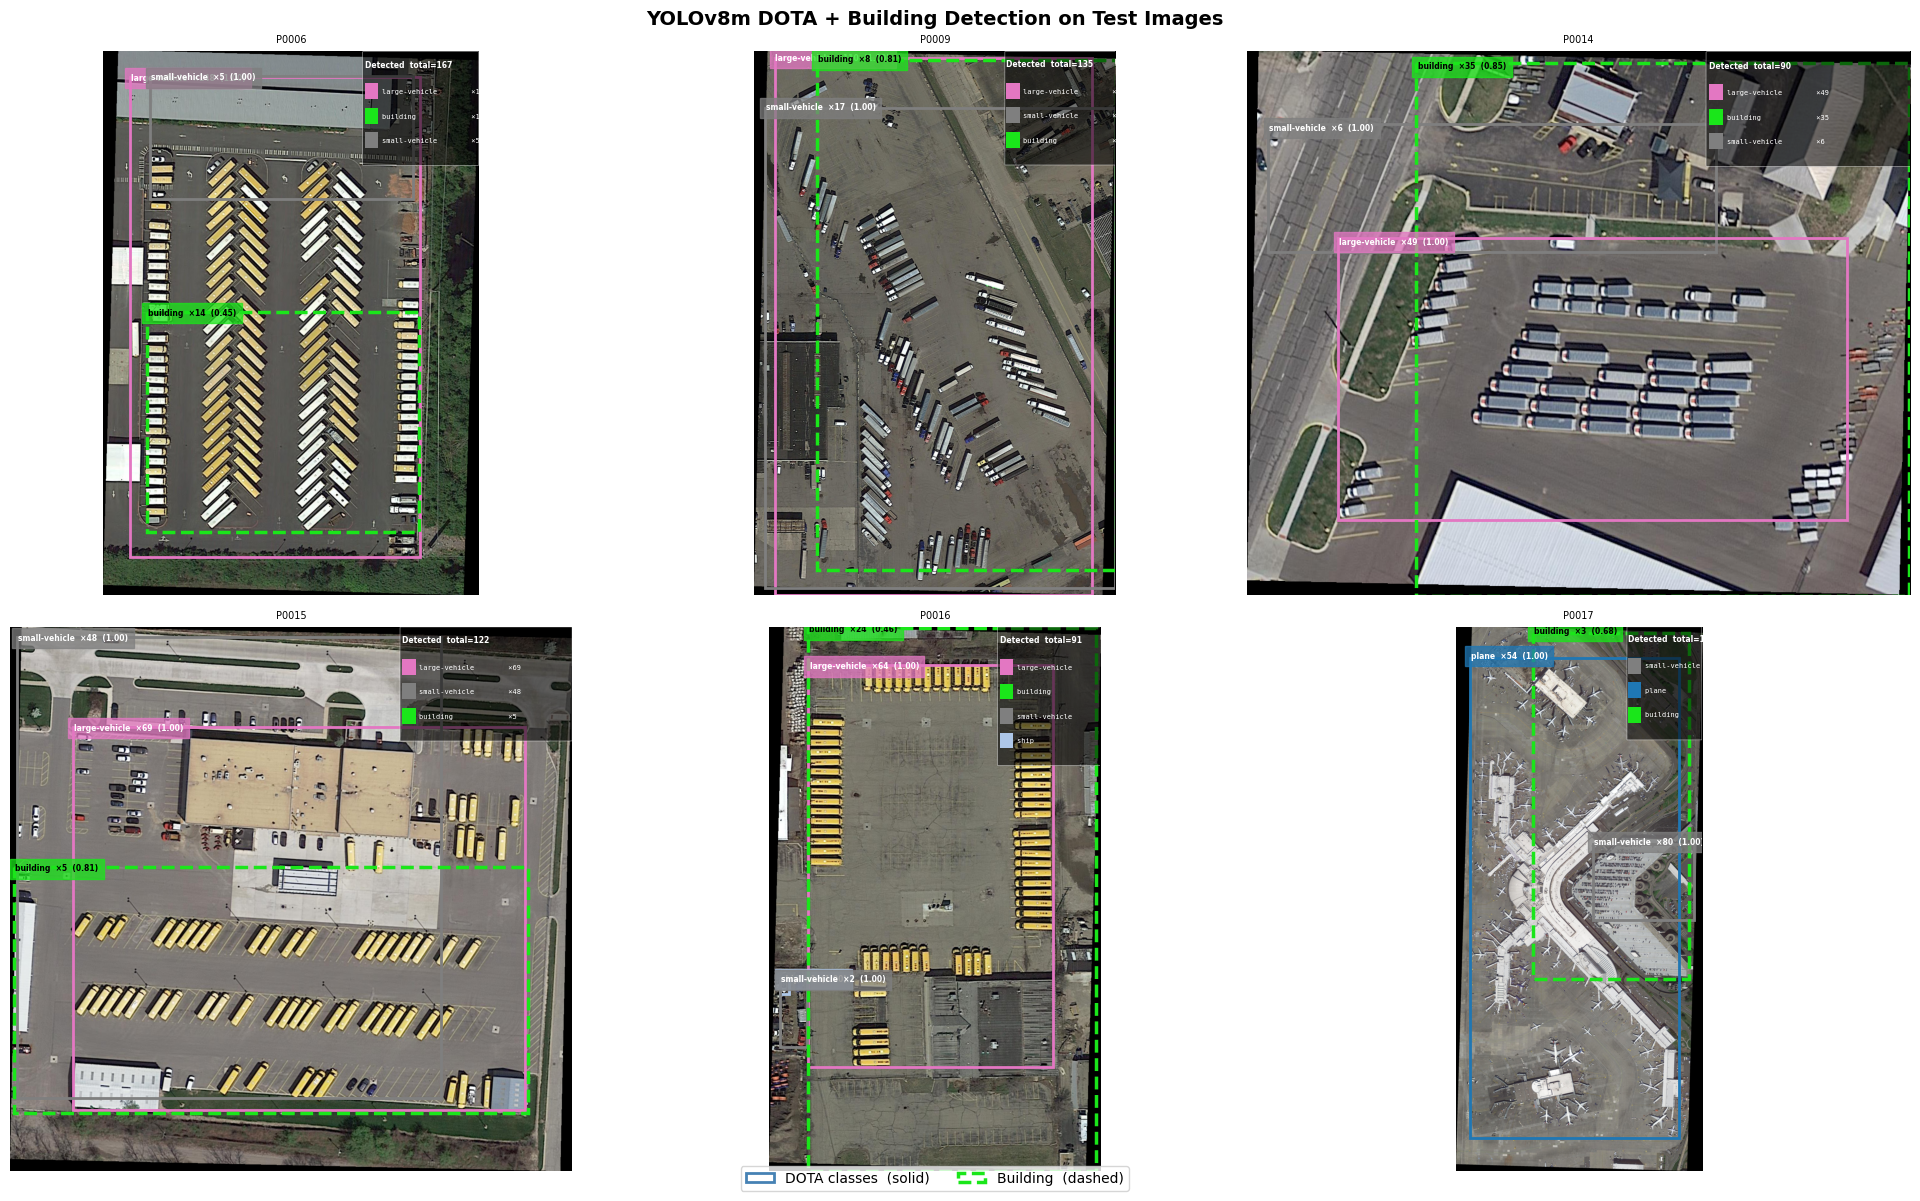

Visualised 6 images.


In [14]:
def draw_predictions(img_path, dota_lbl_path, building_lbl_path, ax):
    """Draw merged DOTA + building boxes on one image axis.
    Each box label shows: class name · count · confidence
    A per-image count table is drawn in the top-right corner.
    """
    img = np.array(Image.open(img_path).convert('RGB'))
    h, w = img.shape[:2]
    ax.imshow(img)

    count_table = []   # (class_name, count, color) collected for the corner table

    # ── DOTA detections – one merged box per class ────────────────────────
    raw_dota = parse_yolo_labels(dota_lbl_path)

    # Count individuals per class before merging
    from collections import defaultdict
    class_confs = defaultdict(list)
    for cls_id, cx, cy, bw, bh, conf in raw_dota:
        class_confs[cls_id].append(conf)

    for cls_id, x1, y1, x2, y2, _ in merge_boxes_by_class(raw_dota):
        confs  = class_confs[cls_id]
        count  = len(confs)
        conf   = max(confs)
        color  = COLORS(cls_id)
        label  = f'{DOTA_CLASSES[cls_id]}  ×{count}  ({conf:.2f})'

        px1, py1 = x1 * w, y1 * h
        pw,  ph  = (x2 - x1) * w, (y2 - y1) * h

        ax.add_patch(patches.Rectangle(
            (px1, py1), pw, ph,
            linewidth=2, edgecolor=color, facecolor='none',
        ))
        ax.text(px1 + 3, py1 + 11, label,
                fontsize=5.5, color='white',
                backgroundcolor=(*color[:3], 0.75),
                clip_on=True, fontweight='bold')

        count_table.append((DOTA_CLASSES[cls_id], count, color))

    # ── Building detections – one merged box for all buildings ────────────
    raw_buildings = parse_yolo_labels(building_lbl_path)
    b_raw  = [(0, cx, cy, bw, bh, conf) for _, cx, cy, bw, bh, conf in raw_buildings]
    b_confs = [conf for _, _, _, _, _, conf in raw_buildings]

    if b_raw:
        for _, x1, y1, x2, y2, _ in merge_boxes_by_class(b_raw):
            count  = len(b_confs)
            conf   = max(b_confs)
            label  = f'building  ×{count}  ({conf:.2f})'

            px1, py1 = x1 * w, y1 * h
            pw,  ph  = (x2 - x1) * w, (y2 - y1) * h

            ax.add_patch(patches.Rectangle(
                (px1, py1), pw, ph,
                linewidth=2.5, edgecolor=BUILDING_COLOR,
                facecolor='none', linestyle='--',
            ))
            ax.text(px1 + 3, py1 + 11, label,
                    fontsize=5.5, color='black',
                    backgroundcolor=(*BUILDING_COLOR, 0.75),
                    clip_on=True, fontweight='bold')

            count_table.append(('building', count, BUILDING_COLOR))

    # ── Count table – top-right corner ───────────────────────────────────
    # Drawn as stacked coloured text lines so you can read totals at a glance
    if count_table:
        total      = sum(c for _, c, _ in count_table)
        line_h     = h * 0.045          # row height in pixels
        box_w      = w * 0.30           # table width
        table_x    = w - box_w - 4      # right-aligned with small margin
        table_y    = 4                  # near top

        # Background panel
        ax.add_patch(patches.FancyBboxPatch(
            (table_x - 4, table_y - 2),
            box_w + 6,
            line_h * (len(count_table) + 1.6),
            boxstyle='round,pad=2',
            facecolor='black', alpha=0.55,
            edgecolor='white', linewidth=0.5,
        ))

        # Header row
        ax.text(table_x, table_y + line_h * 0.5,
                f'Detected  total={total}',
                fontsize=5.5, color='white', fontweight='bold', va='center')

        # One row per class
        for row_i, (cls_name, count, color) in enumerate(
                sorted(count_table, key=lambda x: x[1], reverse=True)):
            y_pos = table_y + line_h * (row_i + 1.6)
            # Colour swatch
            ax.add_patch(patches.Rectangle(
                (table_x, y_pos - line_h * 0.35),
                line_h * 0.55, line_h * 0.65,
                facecolor=color, edgecolor='none',
            ))
            ax.text(table_x + line_h * 0.7, y_pos,
                    f'{cls_name:<20} ×{count}',
                    fontsize=5, color='white', va='center',
                    fontfamily='monospace')

    ax.axis('off')
    ax.set_title(img_path.stem, fontsize=7)


lbl_files = sorted(LABEL_DIR.glob('*.txt'))[:6]
img_paths = [TEST_IMGS / (f.stem + '.png') for f in lbl_files]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for ax, img_path, dota_lbl in zip(axes.flatten(), img_paths, lbl_files):
    draw_predictions(img_path, dota_lbl, BUILDING_LBL_DIR / dota_lbl.name, ax)
for ax in axes.flatten()[len(lbl_files):]:
    ax.axis('off')

from matplotlib.patches import Patch
fig.legend(
    handles=[
        Patch(facecolor='none', edgecolor='steelblue',    linewidth=2,   label='DOTA classes  (solid)'),
        Patch(facecolor='none', edgecolor=BUILDING_COLOR, linewidth=2.5,
              linestyle='--', label='Building  (dashed)'),
    ],
    loc='lower center', ncol=2, fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.01),
)
plt.suptitle('YOLOv8m DOTA + Building Detection on Test Images',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Visualised {len(lbl_files)} images.')


## 14. Save Combined Detections JSON

In [15]:
from collections import defaultdict

# ── Save combined DOTA + building detections for every test image ──────────
combined = {}

# Track global counts per class across all images (for summary)
global_counts = defaultdict(int)

for lbl_path in sorted(LABEL_DIR.glob('*.txt')):
    img_name = lbl_path.stem
    img_file = TEST_IMGS / (img_name + '.png')
    iw, ih   = Image.open(img_file).size

    entry = {'dota': [], 'buildings': []}

    # ── DOTA detections ───────────────────────────────────────────────────
    # Parse raw (unmerged) detections first so we can count individuals
    raw_dota = parse_yolo_labels(lbl_path)

    # Count individual instances per class
    class_counts = defaultdict(list)
    for cls_id, cx, cy, bw, bh, conf in raw_dota:
        class_counts[cls_id].append(conf)

    # Merge into one box per class, but attach the count + confidence stats
    for cls_id, x1, y1, x2, y2, _ in merge_boxes_by_class(raw_dota):
        confs = class_counts[cls_id]
        entry['dota'].append({
            'class'          : DOTA_CLASSES[cls_id],
            'count'          : len(confs),
            'confidence_max' : round(max(confs), 4),
            'confidence_avg' : round(sum(confs) / len(confs), 4),
            'bbox'           : {
                'x1': round(x1 * iw, 1), 'y1': round(y1 * ih, 1),
                'x2': round(x2 * iw, 1), 'y2': round(y2 * ih, 1),
            },
        })
        global_counts[DOTA_CLASSES[cls_id]] += len(confs)

    # ── Building detections ───────────────────────────────────────────────
    raw_buildings = parse_yolo_labels(BUILDING_LBL_DIR / lbl_path.name)
    b_raw = [(0, cx, cy, bw, bh, conf) for _, cx, cy, bw, bh, conf in raw_buildings]
    b_confs = [conf for _, _, _, _, _, conf in raw_buildings]

    if b_raw:
        for _, x1, y1, x2, y2, _ in merge_boxes_by_class(b_raw):
            entry['buildings'].append({
                'class'          : 'building',
                'count'          : len(b_confs),
                'confidence_max' : round(max(b_confs), 4),
                'confidence_avg' : round(sum(b_confs) / len(b_confs), 4),
                'bbox'           : {
                    'x1': round(x1 * iw, 1), 'y1': round(y1 * ih, 1),
                    'x2': round(x2 * iw, 1), 'y2': round(y2 * ih, 1),
                },
            })
        global_counts['building'] += len(b_confs)

    if entry['dota'] or entry['buildings']:
        combined[img_name] = entry

# ── Build summary section ─────────────────────────────────────────────────
summary = {
    'total_images_with_detections' : len(combined),
    'total_objects_detected'       : sum(global_counts.values()),
    'per_class_totals'             : dict(
        sorted(global_counts.items(), key=lambda x: x[1], reverse=True)
    ),
}

output = {'summary': summary, 'images': combined}

out_path = Path('/kaggle/working/detections_combined.json')
with open(out_path, 'w') as f:
    json.dump(output, f, indent=2)

# ── Print summary to console ──────────────────────────────────────────────
print(f'=== Detection Summary ===')
print(f'  Images with detections : {summary["total_images_with_detections"]}')
print(f'  Total objects detected : {summary["total_objects_detected"]}')
print(f'')
print(f'  Per-class breakdown:')
for cls, count in summary['per_class_totals'].items():
    print(f'    {cls:<22} {count:>6}')
print(f'')
print(f'Combined JSON saved → {out_path}')


=== Detection Summary ===
  Images with detections : 918
  Total objects detected : 75698

  Per-class breakdown:
    small-vehicle           21841
    building                15954
    large-vehicle           11718
    ship                    11255
    plane                    4296
    harbor                   3893
    storage-tank             2108
    tennis-court             1460
    swimming-pool            1081
    bridge                    755
    baseball-diamond          368
    ground-track-field        259
    basketball-court          249
    soccer-ball-field         236
    roundabout                184
    helicopter                 41

Combined JSON saved → /kaggle/working/detections_combined.json


## 15. Export Best Model

In [16]:
# Export to ONNX for deployment
model_best.export(format='onnx', imgsz=640, dynamic=True, simplify=True)
print('Model exported to ONNX.')

print('\nAll output files:')
for f in sorted(Path('/kaggle/working').rglob('*')):
    if f.is_file() and f.suffix in ('.pt', '.onnx', '.png', '.csv', '.yaml'):
        size_mb = f.stat().st_size / 1e6
        print(f'  {f.relative_to("/kaggle/working")}  ({size_mb:.1f} MB)')

Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/dota_yolov8m/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 19, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 200ms
 Downloaded onnxruntime-gpu
Prepared 2 packages in 3.38s
Installed 2 packages in 25ms
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 4.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 8.8s, saved as '/kaggle/working/runs/dota_yolov8m/we

## 16. Save Model as .pkl

In [17]:
import joblib

# Load the best trained weights into a YOLO model object
model = YOLO('/kaggle/working/runs/dota_yolov8m/weights/best.pt')

# Save the model with a .pkl extension using the joblib library
filename = '/kaggle/working/my_model.pkl'

# Execution of the save process
joblib.dump(model, filename)
print(f"Model successfully saved in .pkl format using joblib to: {filename}")

# ── Verify it loads back correctly ────────────────────────────────────────
loaded_model = joblib.load(filename)
print(f"Model loaded back successfully: {type(loaded_model)}")
print(f"File size: {Path(filename).stat().st_size / 1e6:.1f} MB")

Model successfully saved in .pkl format using joblib to: /kaggle/working/my_model.pkl
Model loaded back successfully: <class 'ultralytics.models.yolo.model.YOLO'>
File size: 103.9 MB
